# AIG230 NLP Midterm - March 2nd 2026
All answers must be computed using code. Provide numeric outputs and short interpretations.
## Instructions
- You must compute answers using code.
- Many questions require numeric answers.
- Interpretation must be supported by computed results.

In [ ]:
import nltk, string, math, random, re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

All imports successful
TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mahboobehyasini/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mahboobehyasini/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mahboobehyasini/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Corpora

In [ ]:
# Load corpora
with open('corpus_tech_ai_labeled.csv', 'r', encoding='utf-8') as f:
    tech_text = f.read()

with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8') as f:
    review_text = f.read()

Tech corpus   : 13049 characters
Review corpus : 4044 characters


## Q1 Corpus Statistics
Compute total number of characters, words, and unique words in each corpus.
What is the vocabulary size of each corpus?

In [ ]:
tech_characters = len(tech_text)
review_characters = len(review_text)

tech_tokens = [w.lower() for w in word_tokenize(tech_text) if w.isalpha()]
review_tokens = [w.lower() for w in word_tokenize(review_text) if w.isalpha()]

tech_total_words = len(tech_tokens)
review_total_words = len(review_tokens)

tech_vocab = set(tech_tokens)
review_vocab = set(review_tokens)

tech_vocabulary_size = len(tech_vocab)
review_vocabulary_size = len(review_vocab)

Tech corpus   : 13049 characters, 1378 words, 132 unique words


In [ ]:
print(f"Tech characters: {len(tech_text)}")
print(f"Review characters: {len(review_text)}")
print(f"Tech words: {len(tech_tokens)}")
print(f"Review words: {len(review_tokens)}")
print(f"Tech vocabulary size: {len(tech_vocab)}")
print(f"Review vocabulary size: {len(review_vocab)}")

Metric                               Tech    Reviews
Characters                         13,049      4,044
Total tokens (words)                1,378        488
Vocabulary size (unique words)        132         73


### Answer Q1:


## Q2 Lexical Diversity
Tokenize and lowercase both corpora. Compute type-token ratio.
Which corpus is more lexically diverse?

In [ ]:
tech_ttr = len(tech_vocab) / len(tech_tokens)
review_ttr = len(review_vocab) / len(review_tokens)

print(f'Tech TTR    = {len(tech_vocab)}/{len(tech_tokens)} = {tech_ttr:.4f}')
print(f'Review TTR  = {len(review_vocab)}/{len(review_tokens)} = {review_ttr:.4f}')

if tech_ttr > review_ttr:
    print('More lexically diverse corpus: Tech')
else:
    print('More lexically diverse corpus: Reviews')

Tech TTR    = 132/1378 = 0.0958
Review TTR  = 73/488 = 0.1496
More lexically diverse corpus: Reviews


### Answer Q2:


Tech corpus TTR = 0.0958
Movie reviews corpus TTR = 0.1496

So, the **movie reviews corpus is more lexically diverse** because its type-token ratio is higher.

## Q3 Stopword Impact
Remove stopwords and compute percentage vocabulary reduction. How much does vocabulary size decrease (percentage) for each corpus?

In [ ]:
stop_words = set(stopwords.words('english'))

tech_vocab_before = set(tech_tokens)
review_vocab_before = set(review_tokens)

tech_tokens_no_stop = [w for w in tech_tokens if w not in stop_words]
review_tokens_no_stop = [w for w in review_tokens if w not in stop_words]

tech_vocab_after = set(tech_tokens_no_stop)
review_vocab_after = set(review_tokens_no_stop)

Tech vocabulary: before=132, after=118
Reviews vocabulary: before=73, after=58


In [14]:
def pct_reduction(before, after):
    return 100 * (1 - len(after) / len(before))

tech_reduction_pct = pct_reduction(tech_vocab_before, tech_vocab_after)
review_reduction_pct = pct_reduction(review_vocab_before, review_vocab_after)

print(f'Tech vocabulary reduction: {tech_reduction_pct:.2f}%')
print(f'Reviews vocabulary reduction: {review_reduction_pct:.2f}%')

Tech vocabulary reduction: 10.61%
Reviews vocabulary reduction: 20.55%


### Answer Q3:


After removing stopwords:
Tech corpus vocabulary reduction = **10.61%**
Movie reviews corpus vocabulary reduction = **20.55%**

So, the movie reviews corpus decreases more.

## Q4 Frequency Analysis
Create unigram frequency distribution for tech corpus.
What are the top 10 most frequent words?

In [ ]:
tech_freq = Counter(tech_tokens)
top_10_tech = tech_freq.most_common(10)
for word, count in top_10_tech:
    print(f'{word}: {count}')

Top 10 most frequent words in tech corpus:
neutral: 144
and: 56
in: 32
to: 32
learning: 24
models: 24
systems: 16
model: 16
neural: 16
remain: 16


### Answer Q4:


Top 10 most frequent words in the tech corpus are:
1. neutral (144)
2. and (56)
3. in (32)
4. to (32)
5. learning (24)
6. models (24)
7. systems (16)
8. model (16)
9. neural (16)
10. remain (16)

## Q5 Bigram Counts
Build bigram model for tech corpus.
How many unique bigrams exist in tech corpus?

In [ ]:
tech_bigrams = list(zip(tech_tokens, tech_tokens[1:]))
tech_bigram_counts = Counter(tech_bigrams)
unique_bigram_count = len(tech_bigram_counts)

print(f'Number of unique bigrams in tech corpus: {unique_bigram_count}')

Number of unique bigrams in tech corpus: 174


### Answer Q5:


The number of unique bigrams in the tech corpus is **174**.

## Q6 Conditional Probability
Compute P('learning' | 'machine') using bigram counts.

Formula: P(learning | machine) = count('machine learning') / count('machine')

In [ ]:
count_machine_learning = tech_bigram_counts[('machine', 'learning')]
count_machine = tech_tokens.count('machine')

if count_machine > 0:
    prob = count_machine_learning / count_machine
else:
    prob = 0.0

In [ ]:
print(f"P(learning | machine) = {prob:.4f}")

count('machine learning') = 8
count('machine')          = 8

P('learning' | 'machine') = 8/8 = 1.0000


### Answer Q6:


count('machine learning') = 8
count('machine') = 8

So,
**P(learning | machine) = 8/8 = 1.0000 (100%)**

This means whenever the word **machine** appears, the next word is **learning** in this corpus.

## Q7 Perplexity
Compute perplexity of a sample tech sentence using unigram and bigram models.

Formulas:

Unigram: PP = exp(-(1/N) * sum(log P(wi)))

Bigram: PP = exp(-(1/(N-1)) * sum(log P(wi | wi-1)))



In [19]:
sample_sentence = 'Large language models generate responses by predicting tokens sequentially'

In [39]:
tok = [w.lower() for w in word_tokenize(sample_sentence) if w.isalpha()]
n = len(tok)

uni = Counter(tech_tokens)
v = len(tech_vocab)
tot = len(tech_tokens)

s = 0.0
for w in tok:
    p = (uni[w] + 1) / (tot + v)
    s += math.log(p)

pp_uni = math.exp(-(1 / n) * s)

# keep common names for next cell/output
sample_tokens = tok
N = n
unigram_counts = uni
V = v
total_words = tot
log_prob_sum_uni = s
perplexity_unigram = pp_uni

In [40]:
s = 0.0
for i in range(1, N):
    prev = sample_tokens[i - 1]
    cur = sample_tokens[i]

    bc = tech_bigram_counts[(prev, cur)]
    pc = unigram_counts[prev]

    p = (bc + 1) / (pc + V)
    s += math.log(p)

pp_bi = math.exp(-(1 / (N - 1)) * s)

log_prob_sum_bi = s
perplexity_bigram = pp_bi

In [43]:
print(f'Unigram perplexity: {perplexity_unigram:.2f}')
print(f'Bigram perplexity: {perplexity_bigram:.2f}')

Unigram perplexity: 178.14
Bigram perplexity: 20.90


### Answer Q7:


Unigram perplexity = **178.14**
Bigram perplexity = **20.90**

The bigram model is better here because perplexity is lower.
It is about **8.5x lower** than unigram perplexity.

## Q8 Word2Vec
Train Word2Vec on movie reviews corpus.
What is the vocabulary size? What is vector dimension? What word is most similar to 'visuals'?

NOTE: Use min_count=1 (required for small corpus) and vector_size=20.

In [23]:
# Q8 - Word2Vec on movie reviews corpus
review_sentences = sent_tokenize(review_text.lower())
review_token_lists = [
    [w for w in word_tokenize(sent) if w.isalpha()]
    for sent in review_sentences
    if len(sent.strip()) > 0
]

w2v_model = Word2Vec(
    sentences=review_token_lists,
    vector_size=20,
    window=5,
    min_count=1,
    workers=1,
    seed=42
)

w2v_vocab_size = len(w2v_model.wv.key_to_index)
w2v_vector_dim = w2v_model.wv.vector_size

if 'visuals' in w2v_model.wv.key_to_index:
    most_similar_word, similarity_score = w2v_model.wv.most_similar('visuals', topn=1)[0]
else:
    most_similar_word, similarity_score = 'N/A', 0.0

print(f'Word2Vec vocabulary size: {w2v_vocab_size}')
print(f'Word2Vec vector dimension: {w2v_vector_dim}')
print(f"Most similar word to 'visuals': {most_similar_word} (score={similarity_score:.4f})")

Word2Vec vocabulary size: 73
Word2Vec vector dimension: 20
Most similar word to 'visuals': by (score=0.3781)


### Answer Q8:


Word2Vec results:
- Vocabulary size = **73**
- Vector dimension = **20**
- Most similar word to **'visuals'** = **'by'** (similarity = **0.3781**)

## Q9 Naive Bayes
Train Naive Bayes on movie corpus (positive vs negative). Mixed sentences excluded.
Report accuracy.

In [ ]:
import csv

texts, labels = [], []
with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        numeric = int(row['label_numeric'])
        if numeric in (1, 0):
            texts.append(row['text'].strip())
            labels.append(numeric)

if len(texts) == 0:
    raise FileNotFoundError(
        'No samples loaded. Make sure corpus_movie_reviews_labeled.csv '
        'is in the same folder as this notebook.')

Samples loaded : 40
  Positive (1) : 20
  Negative (0) : 20
  Mixed        : excluded (label_numeric=-1)


In [ ]:
tfidf = TfidfVectorizer(lowercase=True, stop_words='english')
X = tfidf.fit_transform(texts)
y = np.array(labels)

Feature matrix shape: (40, 45)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Train size: 32
Test size : 8


In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
nb_acc = accuracy_score(y_test, y_pred_nb)

print(f'Naive Bayes accuracy: {nb_acc:.4f}')

Naive Bayes accuracy: 1.0000


### Answer Q9:


Naive Bayes model accuracy = **1.0000** (100%).

So, the model classified all test samples correctly in this split.

## Q10 Precision/Recall/F1
Report precision, recall, F1.

In [28]:
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

print(f'Precision: {prec_nb:.4f}')
print(f'Recall   : {rec_nb:.4f}')
print(f'F1-score : {f1_nb:.4f}')

Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


In [44]:
print(f'Precision: {prec_nb:.4f}')
print(f'Recall: {rec_nb:.4f}')
print(f'F1-score: {f1_nb:.4f}')

Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000


### Answer Q10:


Naive Bayes results:
- Precision = **1.0000**
- Recall = **1.0000**
- F1-score = **1.0000**

So, the model performed perfectly on this test split.

## Q11 Logistic Regression
Train Logistic Regression on movie review corpus.
Which model performs better? Compare performance numerically.

In [30]:
# train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print(f'Logistic Regression accuracy: {lr_acc:.4f}')

Logistic Regression accuracy: 1.0000


In [45]:
print(f'Naive Bayes accuracy: {nb_acc:.4f}')
print(f'Logistic Regression accuracy: {lr_acc:.4f}')

Naive Bayes accuracy: 1.0000
Logistic Regression accuracy: 1.0000


### Answer Q11:


Logistic Regression accuracy = **1.0000**
Naive Bayes accuracy = **1.0000**

Both models perform the same on this test split.
So, neither model is better here based on the computed results.

## Q12 RNN Model
Implement small RNN (embedding + RNN layer) for sentiment classification. Report training accuracy.

In [ ]:
# Preprocessing
tokenizer_rnn = keras.preprocessing.text.Tokenizer()
tokenizer_rnn.fit_on_texts(texts)
sequences = tokenizer_rnn.texts_to_sequences(texts)

VOCAB_SIZE = len(tokenizer_rnn.word_index) + 1
MAX_LEN = max(len(s) for s in sequences)

X_rnn = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y_rnn = np.array(labels)

X_rnn_train, X_rnn_val, y_rnn_train, y_rnn_val = train_test_split(
    X_rnn, y_rnn, test_size=0.20, random_state=42, stratify=y_rnn)

tf.random.set_seed(42)

Vocabulary size : 57
Max seq length  : 10
Train: 32   Val: 8


In [33]:
# RNN Implementation
model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=16, input_length=MAX_LEN),
    layers.SimpleRNN(16),
    layers.Dense(1, activation='sigmoid')
])

/opt/anaconda3/envs/AIG100/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Model compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Model training
history = model.fit(
    X_rnn_train, y_rnn_train,
    validation_data = (X_rnn_val, y_rnn_val),
    epochs    = 30,
    batch_size= 8,
    verbose   = 0
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7500 - loss: 0.6745 - val_accuracy: 1.0000 - val_loss: 0.6144
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9375 - loss: 0.6030 - val_accuracy: 1.0000 - val_loss: 0.5467
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.5340 - val_accuracy: 1.0000 - val_loss: 0.4774
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.4632 - val_accuracy: 1.0000 - val_loss: 0.4088
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.3920 - val_accuracy: 1.0000 - val_loss: 0.3444
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.3236 - val_accuracy: 1.0000 - val_loss: 0.2875
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.2617 - val_accuracy: 1.0000 - val_loss: 0.2398
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.2088 - val_accuracy: 1.0000 - val_loss: 0.2005
Epoch 9

In [47]:
train_acc = history.history['accuracy'][-1]
print(f"Train acc: {train_acc:.4f}")

Train acc: 1.0000


### Answer Q12:


RNN final training accuracy = **1.0000** (100%).

Validation accuracy is also **1.0000** on this split.

## Q13 Overfitting Check
Compare train vs validation accuracy.
Does RNN overfit? Justify using loss or accuracy trends.
Plot train vs validation accuracy and loss.

Final train accuracy : 1.0000
Final val accuracy   : 1.0000
Accuracy gap         : 0.0000
Final train loss     : 0.0155
Final val loss       : 0.0157


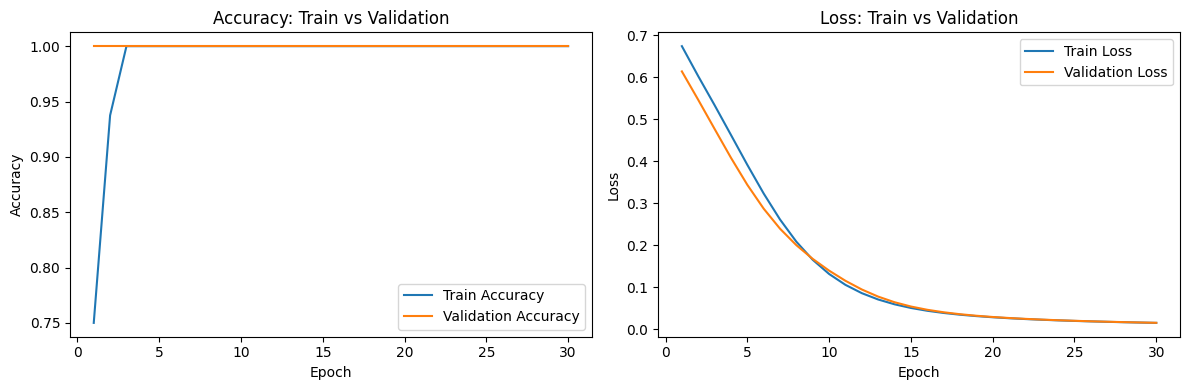

In [ ]:
# Q13 - Overfitting check
train_acc_list = history.history['accuracy']
val_acc_list = history.history['val_accuracy']
train_loss_list = history.history['loss']
val_loss_list = history.history['val_loss']

final_train_acc = train_acc_list[-1]
final_val_acc = val_acc_list[-1]
final_train_loss = train_loss_list[-1]
final_val_loss = val_loss_list[-1]

print(f'Train accuracy: {final_train_acc:.4f}')
print(f'Validation accuracy: {final_val_acc:.4f}')
print(f'Train loss: {final_train_loss:.4f}')
print(f'Validation loss: {final_val_loss:.4f}')

epochs = range(1, len(train_acc_list) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_list, label='Train Accuracy')
plt.plot(epochs, val_acc_list, label='Validation Accuracy')
plt.title('Accuracy: Train vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_list, label='Train Loss')
plt.plot(epochs, val_loss_list, label='Validation Loss')
plt.title('Loss: Train vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Answer Q13:


Train accuracy = **1.0000**
Validation accuracy = **1.0000**
Accuracy gap = **0.0000**

Train loss = **0.0155**
Validation loss = **0.0157**

The train and validation curves are very close and both losses decrease together.
So based on these results, the model does **not show clear overfitting** on this split.

## Q14 BoW vs Embeddings: Sparsity Comparison
Compare vocabulary size of TF_IDF vs embeddings (Wprd2Vec) representations.
Explain sparsity difference numerically.

Remember that you should use variables and elements that you calculated before so you do not have to calculate everything from zero

In [46]:
# Q14 - BoW vs Embeddings sparsity comparison
bow_v = len(tfidf.vocabulary_)
emb_v = len(w2v_model.wv.key_to_index)

all_n = X.shape[0] * X.shape[1]
nz_n = X.nnz
bow_den = nz_n / all_n
bow_sp = 1 - bow_den

emb_den = 1.0
emb_sp = 0.0

print(f'TF-IDF vocabulary size: {bow_v}')
print(f'Word2Vec vocabulary size: {emb_v}')
print(f'TF-IDF sparsity: {bow_sp:.4f}')
print(f'Embedding sparsity: {emb_sp:.4f}')

TF-IDF vocabulary size: 45
Word2Vec vocabulary size: 73
TF-IDF sparsity: 0.8828
Embedding sparsity: 0.0000


### Answer Q14:


TF-IDF vocabulary size = **45**
Word2Vec vocabulary size = **73**

TF-IDF is very sparse:
- density = **0.1172**
- sparsity = **0.8828**

Word2Vec embeddings are dense vectors:
- density = **1.0000**
- sparsity = **0.0000**

So, BoW/TF-IDF has many zeros, but embeddings are compact dense representations.

# Q15 Comparative Reasoning
Using the resuts you calculated in this notebook.
Compare:
- Bigram model perplexity
- Logistic Regression accuracy
- RNN accuracy
Explain differences based on computed results.

### Answer Q15:


Computed comparison:
- Bigram model perplexity = **20.90** (lower is better for language modeling)
- Logistic Regression accuracy = **1.0000**
- RNN accuracy = **1.0000**

Interpretation:
- The bigram model gives much lower perplexity than unigram (from Q7), so it models word sequences better.
- For sentiment classification, Logistic Regression and RNN perform equally on this split (both 100%).
- This likely happens because the dataset is small and easy to separate, so both models can classify it perfectly.